<a href="https://colab.research.google.com/github/ShahidhaShireen/DSS-crop-management-/blob/main/DECISION_SUPPORT_SYSTEM_FOR_CROP_MANAGEMENT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

YIELD PREDICTION


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Load datasets
southindia_rice = pd.read_csv("southindia_rice.csv")
rainfallstate_data = pd.read_csv("rainfallstate_data.csv")

# Merge datasets on 'State' and 'Year'
data = pd.merge(southindia_rice, rainfallstate_data, on=['State', 'Year'])

# Function to convert duration ranges to average values
def convert_duration(duration):
    if '-' in duration:
        start, end = map(int, duration.split('-'))
        return (start + end) / 2
    return float(duration)

# Apply the function to the Duration column
data['duration'] = data['duration'].apply(convert_duration)

# Encode categorical features, including 'State' and 'District'
data_encoded = pd.get_dummies(data, columns=['State', 'District', 'Soil_type', 'Rice_Type'], drop_first=True)

# Separate features (X) and target (y)
X = data_encoded.drop(['Yield (Tonne/Hectare)'], axis=1)
y = data_encoded['Yield (Tonne/Hectare)']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=20)  # Adjust the number of components as needed
X_pca = pca.fit_transform(X_scaled)

# Reshape for CNN input
X_cnn = X_pca.reshape((X_pca.shape[0], X_pca.shape[1], 1))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y, test_size=0.2, random_state=42)

# Get the test indices from the original data to retrieve State and District information
_, test_indices = train_test_split(data.index, test_size=0.2, random_state=42)

# Define a CNN model
model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_pca.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1)  # Single output for yield prediction
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model on the test data
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f'Test Mean Absolute Error: {test_mae}')

# Predict yield for the first 5 samples in the test set
predictions = model.predict(X_test[:5])

# Extract the corresponding states and districts from the original data using test indices
test_data = data.loc[test_indices[:5]]  # Use the first 5 test indices

# Create a DataFrame to display the results
results = pd.DataFrame({
    'State': test_data['State'].values,
    'District': test_data['District'].values,
    'Predicted Yield': predictions.flatten(),
    'Actual Yield': y_test[:5].values
})

# Print the results
print(results)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 8.1810 - mae: 2.6387 - val_loss: 2.6996 - val_mae: 1.3514
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.6097 - mae: 1.5690 - val_loss: 2.1178 - val_mae: 1.2459
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5655 - mae: 1.2724 - val_loss: 1.3476 - val_mae: 0.9285
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7636 - mae: 1.0480 - val_loss: 1.3768 - val_mae: 0.9897
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3983 - mae: 0.9637 - val_loss: 1.0320 - val_mae: 0.7535
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2807 - mae: 0.8778 - val_loss: 0.9013 - val_mae: 0.7437
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1565 - mae: 0.8591 - val_loss: 0.7240 - val_mae: 0.6366
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8899 - mae: 0.7397 - val_loss: 0.6712 - val_mae: 0.6362
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7415 - mae: 0.6505 - v

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

YIELD WITH OPTIMIZING RESOURCES

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Load datasets
southindia_rice = pd.read_csv("southindia_rice.csv")
rainfallstate_data = pd.read_csv("rainfallstate_data.csv")

# Merge datasets on 'State' and 'Year'
data = pd.merge(southindia_rice, rainfallstate_data, on=['State', 'Year'])

# Function to convert duration ranges to average values
def convert_duration(duration):
    if '-' in duration:
        start, end = map(int, duration.split('-'))
        return (start + end) / 2
    return float(duration)

# Apply the function to the Duration column
data['duration'] = data['duration'].apply(convert_duration)

# Encode categorical features, including 'State' and 'District'
data_encoded = pd.get_dummies(data, columns=['State', 'District', 'Soil_type', 'Rice_Type'], drop_first=True)

# Separate features (X) and target (y)
X = data_encoded.drop(['Yield (Tonne/Hectare)'], axis=1)
y = data_encoded['Yield (Tonne/Hectare)']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=20)  # Adjust the number of components as needed
X_pca = pca.fit_transform(X_scaled)

# Reshape for CNN input
X_cnn = X_pca.reshape((X_pca.shape[0], X_pca.shape[1], 1))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y, test_size=0.2, random_state=42)

# Get the test indices from the original data to retrieve State and District information
_, test_indices = train_test_split(data.index, test_size=0.2, random_state=42)

# Define a CNN model
model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_pca.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1)  # Single output for yield prediction
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Evaluate the model on the test data
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f'Test Mean Absolute Error: {test_mae}')

# Predict yield for the first 5 samples in the test set
predictions = model.predict(X_test[:5])

# Extract the corresponding states, districts, and areas from the original data using test indices
test_data = data.loc[test_indices[:5]]  # Use the first 5 test indices

# Calculate the resources required based on predicted yield and area
# Constants
water_per_kg = 2500  # liters needed per kg of rice
nitrogen_per_ton = 20  # kg of nitrogen needed per ton
phosphorus_per_ton = 3  # kg of phosphorus needed per ton
potassium_per_ton = 20  # kg of potassium needed per ton
labor_days_per_hectare = 175  # average labor days needed per hectare for traditional method

# Calculate resources for each sample
test_data['Predicted Yield (Tonne/Hectare)'] = predictions.flatten()
test_data['Water Required (liters)'] = test_data['Area (Hectare)'] * test_data['Predicted Yield (Tonne/Hectare)'] * water_per_kg * 1000  # Convert to liters
test_data['Nitrogen Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * nitrogen_per_ton * test_data['Area (Hectare)']
test_data['Phosphorus Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * phosphorus_per_ton * test_data['Area (Hectare)']
test_data['Potassium Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * potassium_per_ton * test_data['Area (Hectare)']
test_data['Labor Required (days)'] = labor_days_per_hectare * test_data['Area (Hectare)']

# Create a DataFrame to display the results with area included
results = pd.DataFrame({
    'State': test_data['State'].values,
    'District': test_data['District'].values,
    'Area (hectares)': test_data['Area (Hectare)'].values,  # Corrected the column name
    'Predicted Yield (Tonne/Hectare)': test_data['Predicted Yield (Tonne/Hectare)'].values,
    'Water Required (liters)': test_data['Water Required (liters)'].values,
    'Nitrogen Required (kg)': test_data['Nitrogen Required (kg)'].values,
    'Phosphorus Required (kg)': test_data['Phosphorus Required (kg)'].values,
    'Potassium Required (kg)': test_data['Potassium Required (kg)'].values,
    'Labor Required (days)': test_data['Labor Required (days)'].values
})

# Print the results
print(results)


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 9.2328 - mae: 2.8410 - val_loss: 2.8538 - val_mae: 1.4287
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.8006 - mae: 1.5717 - val_loss: 2.2381 - val_mae: 1.2706
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3670 - mae: 1.2783 - val_loss: 1.5506 - val_mae: 1.0260
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7765 - mae: 1.0308 - val_loss: 1.3115 - val_mae: 0.9304
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5555 - mae: 0.9761 - val_loss: 1.0491 - val_mae: 0.7983
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.2868 - mae: 0.8499 - val_loss: 0.9920 - val_mae: 0.7827
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1553 - mae: 0.7889 - val_loss: 0.7623 - val_mae: 0.6558
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9283 - mae: 0.7585 - val_loss: 0.8296 - val_mae: 0.7183
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8927 - mae: 0.7207 - v

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
             State       District  Area (hectares)  \
0        Telangana       Adilabad             1230   
1   Andhra Pradesh  East godavari            76252   
2   Andhra Pradesh         Guntur           222643   
3       Tamil Nadu   Virudhunagar            13826   
4   Andhra Pradesh  West godavari           226760   

   Predicted Yield (Tonne/Hectare)  Water Required (liters)  \
0                         2.654419             8.162338e+09   
1                         3.399684             6.480818e+11   
2                         3.425794             1.906822e+12   
3                         3.773349             1.304258e+11   
4                         3.248343             1.841485e+12   

   Nitrogen Required (kg)  Phosphorus Required (kg)  Potassium Required (kg)  \
0            6.529871e+04              9.794806e+03             6.529871e+04   
1            5.184654e+06              7.776982e+05             5.184654e+06   
2            1.525

PREDICTING HARVEST TIME


In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
southindia_rice = pd.read_csv("southindia_rice.csv")

# Function to generate a random planting date for each row
def generate_random_planting_date(year):
    # Generate a random month (1-12)
    month = np.random.randint(1, 13)  # Random month between 1 and 12
    # Generate a random day depending on the month
    if month in [1, 3, 5, 7, 8, 10, 12]:
        day = np.random.randint(1, 32)  # 31 days
    elif month in [4, 6, 9, 11]:
        day = np.random.randint(1, 31)  # 30 days
    else:  # February, considering leap year is not accounted for simplicity
        day = np.random.randint(1, 29)  # 28 days

    return pd.to_datetime(f"{year}-{month:02d}-{day:02d}")  # Format month and day as two digits

# Apply the function to create a random planting date for each row
southindia_rice['Planting_Date'] = southindia_rice['Year'].apply(generate_random_planting_date)

# Function to calculate the estimated harvest date
def calculate_harvest_date(row):
    duration = row['duration']
    if isinstance(duration, str):  # Check if duration is a string
        if '-' in duration:  # Handle range of duration
            start, end = map(int, duration.split('-'))
            avg_duration = (start + end) / 2  # Take the average duration
        else:
            avg_duration = float(duration)
    else:
        avg_duration = 0  # Default to 0 if duration is NaN or not a string

    return row['Planting_Date'] + pd.Timedelta(days=avg_duration)

# Apply the function to calculate harvest date
southindia_rice['Harvest_Date'] = southindia_rice.apply(calculate_harvest_date, axis=1)

# Select the first 5 samples for display
harvest_info = southindia_rice[['State', 'District', 'Planting_Date', 'Harvest_Date']].head(5)

# Print the results
print(harvest_info)


             State               District Planting_Date        Harvest_Date
0   Andhra Pradesh  Alluri sitharama raju    2023-06-30 2023-11-14 12:00:00
1   Andhra Pradesh             Anakapalli    2023-08-11 2023-12-26 12:00:00
2   Andhra Pradesh              Anantapur    2015-04-11 2015-08-26 12:00:00
3   Andhra Pradesh              Anantapur    2016-07-18 2016-12-02 12:00:00
4   Andhra Pradesh              Anantapur    2017-07-23 2017-12-07 12:00:00


In [ ]:
import pandas as pd

# Load the dataset
southindia_rice = pd.read_csv("southindia_rice.csv")

# Ensure the 'Year' column is treated as a date; creating a planting date
southindia_rice['Planting_Date'] = pd.to_datetime(southindia_rice['Year'].astype(str) + '-06-01')  # Example: June 1st for planting

# Function to calculate the estimated harvest date
def calculate_harvest_date(row):
    duration = row['duration']
    if isinstance(duration, str):  # Check if duration is a string
        if '-' in duration:  # Handle range of duration
            start, end = map(int, duration.split('-'))
            avg_duration = (start + end) / 2  # Take the average duration
        else:
            avg_duration = float(duration)
    else:
        avg_duration = 0  # Default to 0 if duration is NaN or not a string

    return row['Planting_Date'] + pd.Timedelta(days=avg_duration)

# Apply the function to calculate harvest date for the entire dataset
southindia_rice['Harvest_Date'] = southindia_rice.apply(calculate_harvest_date, axis=1)

# Select the first 5 samples for display
harvest_info = southindia_rice[['State', 'District', 'Planting_Date', 'Harvest_Date']].head(5)

# Print the results
print(harvest_info)


             State               District Planting_Date        Harvest_Date
0   Andhra Pradesh  Alluri sitharama raju    2023-06-01 2023-10-16 12:00:00
1   Andhra Pradesh             Anakapalli    2023-06-01 2023-10-16 12:00:00
2   Andhra Pradesh              Anantapur    2015-06-01 2015-10-16 12:00:00
3   Andhra Pradesh              Anantapur    2016-06-01 2016-10-16 12:00:00
4   Andhra Pradesh              Anantapur    2017-06-01 2017-10-16 12:00:00


VAUES

In [ ]:
# Load libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Load datasets
southindia_rice = pd.read_csv("southindia_rice.csv")
rainfallstate_data = pd.read_csv("rainfallstate_data.csv")

# Merge datasets on 'State' and 'Year'
data = pd.merge(southindia_rice, rainfallstate_data, on=['State', 'Year'])

# Function to convert duration ranges to average values
def convert_duration(duration):
    if '-' in duration:
        start, end = map(int, duration.split('-'))
        return (start + end) / 2
    return float(duration)

# Apply the function to the Duration column
data['duration'] = data['duration'].apply(convert_duration)

# Encode categorical features
data_encoded = pd.get_dummies(data, columns=['State', 'District', 'Soil_type', 'Rice_Type'], drop_first=True)

# Separate features and target
X = data_encoded.drop(['Yield (Tonne/Hectare)'], axis=1)
y = data_encoded['Yield (Tonne/Hectare)']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_scaled)

# Reshape for CNN input
X_cnn = X_pca.reshape((X_pca.shape[0], X_pca.shape[1], 1))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y, test_size=0.2, random_state=42)

# Define a CNN model
model = Sequential([
    Conv1D(32, kernel_size=3, activation='relu', input_shape=(X_pca.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1)  # Single output for yield prediction
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 7.8828 - mae: 2.5663 - val_loss: 2.6547 - val_mae: 1.3602
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.3620 - mae: 1.4866 - val_loss: 2.2324 - val_mae: 1.2858
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3000 - mae: 1.2651 - val_loss: 1.3750 - val_mae: 0.9563
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.5093 - mae: 0.9828 - val_loss: 1.1515 - val_mae: 0.8614
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.3477 - mae: 0.9360 - val_loss: 0.8805 - val_mae: 0.7221
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1787 - mae: 0.8242 - val_loss: 0.7423 - val_mae: 0.6669
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9123 - mae: 0.7526 - val_loss: 0.6215 - val_mae: 0.5936
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8212 - mae: 0.6954 - val_loss: 0.5740 - val_mae: 0.5512
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7239 - mae

DATA VISUALIZATION

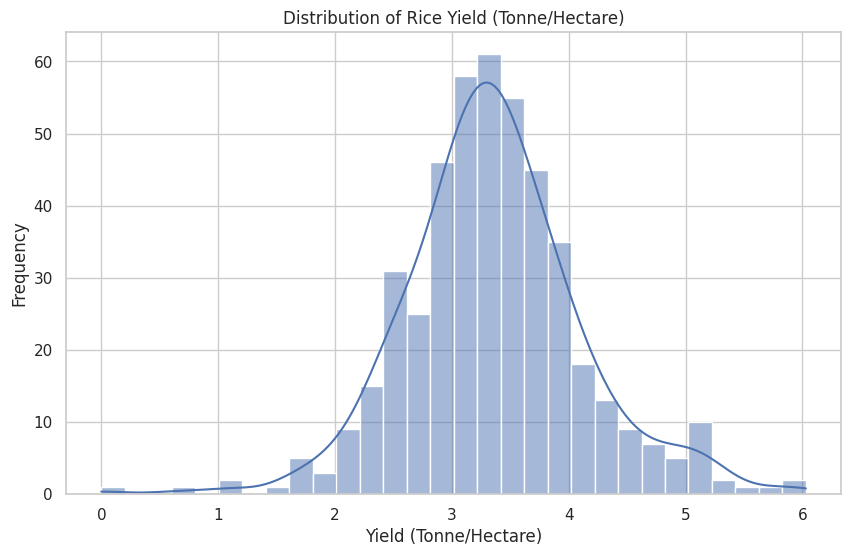

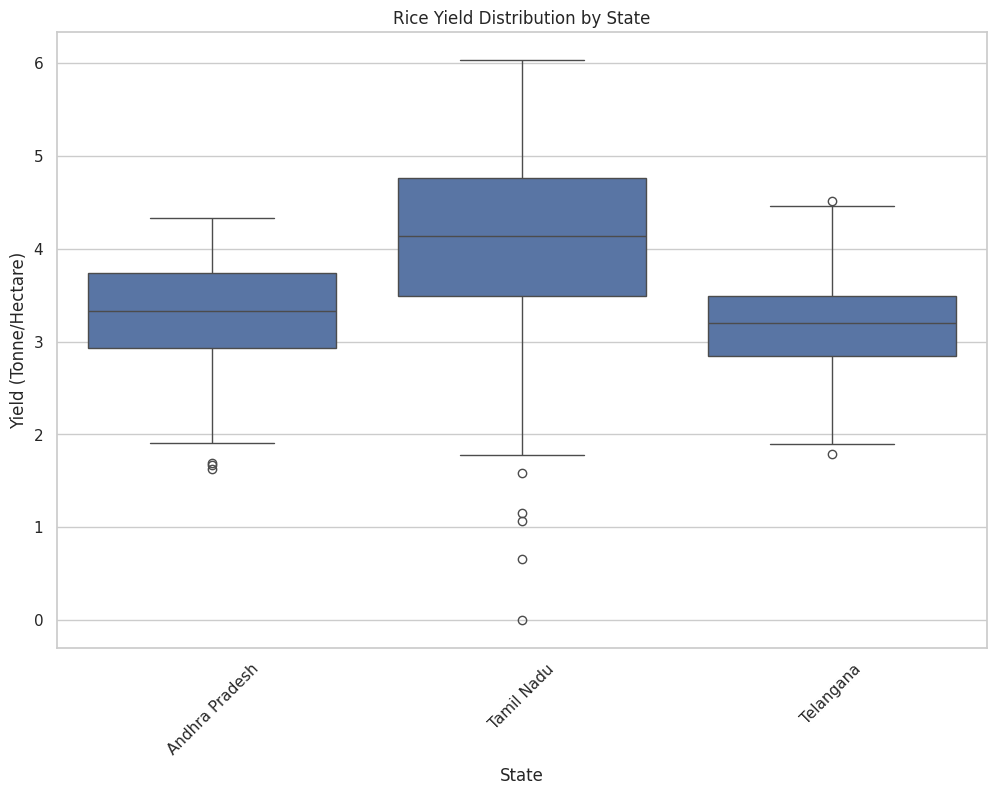

ValueError: could not convert string to float: ' Andhra Pradesh'

<Figure size 1200x1000 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
southindia_rice = pd.read_csv("southindia_rice.csv")
rainfallstate_data = pd.read_csv("rainfallstate_data.csv")

# Merge datasets on 'State' and 'Year'
data = pd.merge(southindia_rice, rainfallstate_data, on=['State', 'Year'])

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# 1. Yield Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['Yield (Tonne/Hectare)'], bins=30, kde=True)
plt.title('Distribution of Rice Yield (Tonne/Hectare)')
plt.xlabel('Yield (Tonne/Hectare)')
plt.ylabel('Frequency')
plt.show()

# 2. Boxplot of Yield by State
plt.figure(figsize=(12, 8))
sns.boxplot(x='State', y='Yield (Tonne/Hectare)', data=data)
plt.title('Rice Yield Distribution by State')
plt.xlabel('State')
plt.ylabel('Yield (Tonne/Hectare)')
plt.xticks(rotation=45)
plt.show()

# 3. Heatmap of Correlation Matrix
plt.figure(figsize=(12, 10))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title('Correlation Matrix of Features')
plt.show()

# 4. Resource Requirement Visualization
# Assuming 'results' DataFrame is created as in previous code
results = pd.DataFrame({
    'State': ['State1', 'State2', 'State3'],  # Example states
    'Water Required (liters)': [5000, 6000, 7000],  # Example values
    'Nitrogen Required (kg)': [200, 250, 300],  # Example values
    'Phosphorus Required (kg)': [30, 35, 40],  # Example values
    'Potassium Required (kg)': [250, 300, 350],  # Example values
    'Labor Required (days)': [150, 175, 200]  # Example values
})

# Melt the DataFrame for better plotting
resources_melted = results.melt(id_vars='State', var_name='Resource', value_name='Amount')

plt.figure(figsize=(12, 8))
sns.barplot(x='Resource', y='Amount', hue='State', data=resources_melted)
plt.title('Resource Requirements per State')
plt.xlabel('Resource Type')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.legend(title='State')
plt.show()

# 5. Predicted vs Actual Yield
# Assuming `y_test` and `predictions` are available
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Predicted vs Actual Yield')
plt.xlabel('Actual Yield (Tonne/Hectare)')
plt.ylabel('Predicted Yield (Tonne/Hectare)')
plt.grid()
plt.show()


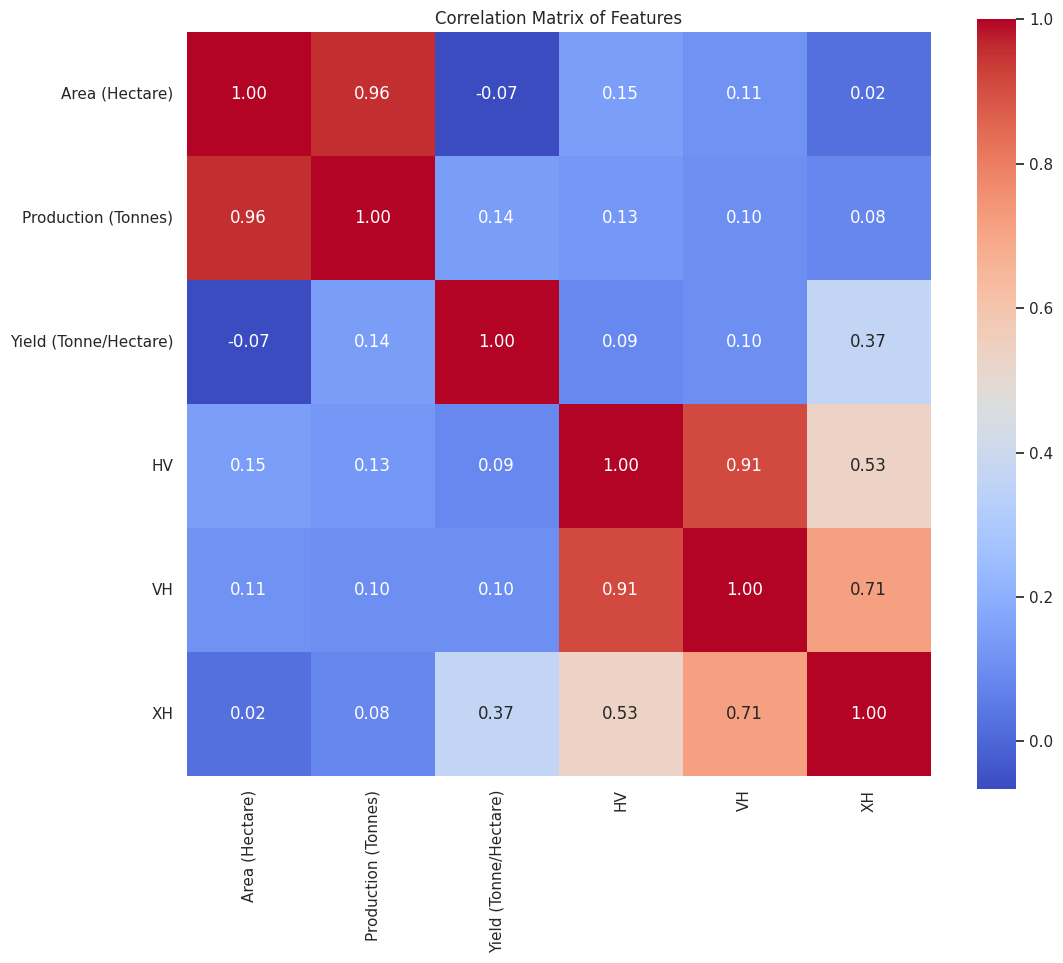

In [ ]:
# Load the datasets
southindia_rice = pd.read_csv("southindia_rice.csv")
rainfallstate_data = pd.read_csv("rainfallstate_data.csv")

# Merge datasets on 'State' and 'Year'
data = pd.merge(southindia_rice, rainfallstate_data, on=['State', 'Year'])

# Convert relevant columns to numeric, ignoring errors
numeric_columns = ['Area (Hectare)', 'Production (Tonnes)', 'Yield (Tonne/Hectare)', 'HV', 'VH', 'XH']
for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop rows with NaN values after conversion to ensure clean data for correlation
data.dropna(subset=numeric_columns, inplace=True)

# 3. Heatmap of Correlation Matrix
plt.figure(figsize=(12, 10))
correlation_matrix = data[numeric_columns].corr()  # Use only numeric columns
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title('Correlation Matrix of Features')
plt.show()


new implementation

improved

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Load datasets
southindia_rice = pd.read_csv("southindia_rice.csv")
rainfallstate_data = pd.read_csv("rainfallstate_data.csv")
temperature_data = pd.read_csv("temperature.csv")  # Replace with actual filename

# Merge datasets on 'State' and 'Year'
data = pd.merge(southindia_rice, rainfallstate_data, on=['State', 'Year'])
data = pd.merge(data, temperature_data, on='Year')

# Check for missing data
data = data.dropna()  # Remove rows with missing values

# Convert duration ranges to average values
def convert_duration(duration):
    if '-' in duration:
        start, end = map(int, duration.split('-'))
        return (start + end) / 2
    return float(duration)

# Apply the function to the Duration column
data['duration'] = data['duration'].apply(convert_duration)

# Encode categorical features, including 'State' and 'District'
data_encoded = pd.get_dummies(data, columns=['State', 'District', 'Soil_type', 'Rice_Type'], drop_first=True)

# Select features including temperature
features = [col for col in data_encoded.columns if col not in ['Yield (Tonne/Hectare)']]
X = data_encoded[features]
y = data_encoded['Yield (Tonne/Hectare)']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Squared Exponential Kernel PCA
sekpca = KernelPCA(n_components=30, kernel='rbf', gamma=0.05)  # Experiment with gamma and components
X_sekpca = sekpca.fit_transform(X_scaled)

# Reshape for CNN input
X_cnn = X_sekpca.reshape((X_sekpca.shape[0], X_sekpca.shape[1], 1))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y, test_size=0.2, random_state=42)

# Define the Weight-Tuned Deep CNN model
model = Sequential([
    Conv1D(64, kernel_size=3, input_shape=(X_sekpca.shape[1], 1)),
    LeakyReLU(alpha=0.1),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3),
    LeakyReLU(alpha=0.1),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(256),
    Dropout(0.5),
    Dense(1)  # Single output for yield prediction
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test),
                    callbacks=[early_stopping, lr_scheduler])

# Evaluate the model
y_pred = model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = mean_squared_error(y_test, y_pred, squared=False)
test_r2 = r2_score(y_test, y_pred)

# Display evaluation metrics
print(f'R-squared: {test_r2:.4f}')
print(f'RMSE: {test_rmse:.4f}')
print(f'MAE: {test_mae:.4f}')

# Predict yield and calculate resources
water_per_kg = 2500
nitrogen_per_ton = 20
phosphorus_per_ton = 3
potassium_per_ton = 20
labor_days_per_hectare = 175

# Prepare results DataFrame
test_indices = y_test.index
test_data = data.loc[test_indices]

test_data['Predicted Yield (Tonne/Hectare)'] = y_pred.flatten()
test_data['Water Required (liters)'] = test_data['Area (Hectare)'] * test_data['Predicted Yield (Tonne/Hectare)'] * water_per_kg * 1000
test_data['Nitrogen Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * nitrogen_per_ton * test_data['Area (Hectare)']
test_data['Phosphorus Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * phosphorus_per_ton * test_data['Area (Hectare)']
test_data['Potassium Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * potassium_per_ton * test_data['Area (Hectare)']
test_data['Labor Required (days)'] = labor_days_per_hectare * test_data['Area (Hectare)']

results = pd.DataFrame({
    'State': test_data['State'],
    'District': test_data['District'],
    'Area (hectares)': test_data['Area (Hectare)'],
    'Predicted Yield (Tonne/Hectare)': test_data['Predicted Yield (Tonne/Hectare)'],
    'Water Required (liters)': test_data['Water Required (liters)'],
    'Nitrogen Required (kg)': test_data['Nitrogen Required (kg)'],
    'Phosphorus Required (kg)': test_data['Phosphorus Required (kg)'],
    'Potassium Required (kg)': test_data['Potassium Required (kg)'],
    'Labor Required (days)': test_data['Labor Required (days)']
})

print(results.head())


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 10.4197 - mae: 3.0673 - val_loss: 2.0141 - val_mae: 1.1459 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 2.4053 - mae: 1.2667 - val_loss: 1.4631 - val_mae: 0.9719 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.5855 - mae: 0.9684 - val_loss: 1.0725 - val_mae: 0.8353 - learning_rate: 0.0010
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.3948 - mae: 0.9342 - val_loss: 0.8158 - val_mae: 0.7176 - learning_rate: 0.0010
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0963 - mae: 0.8161 - val_loss: 0.6455 - val_mae: 0.6388 - learning_rate: 0.0010
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7992 - mae: 0.6773 - val_loss: 0.6107 - val_mae: 0.6230 - learning_rate: 0.0010
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8734 - mae: 0.7056 - val_loss: 0.4811 - val_mae: 0.5606 - learning_rate: 0.0010
Epoch 8/100
9/9 ━━━

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [ ]:
# Ensure y_pred_lstm is 1-dimensional
y_pred_lstm = y_pred_lstm.flatten()

# Calculate MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - y_pred_lstm) / y_test)) * 100

# Calculate Accuracy Percentage
accuracy_percentage = 100 - mape

print(f'MAPE: {mape:.2f}%')
print(f'Accuracy Percentage: {accuracy_percentage:.2f}%')


MAPE: 19.04%
Accuracy Percentage: 80.96%


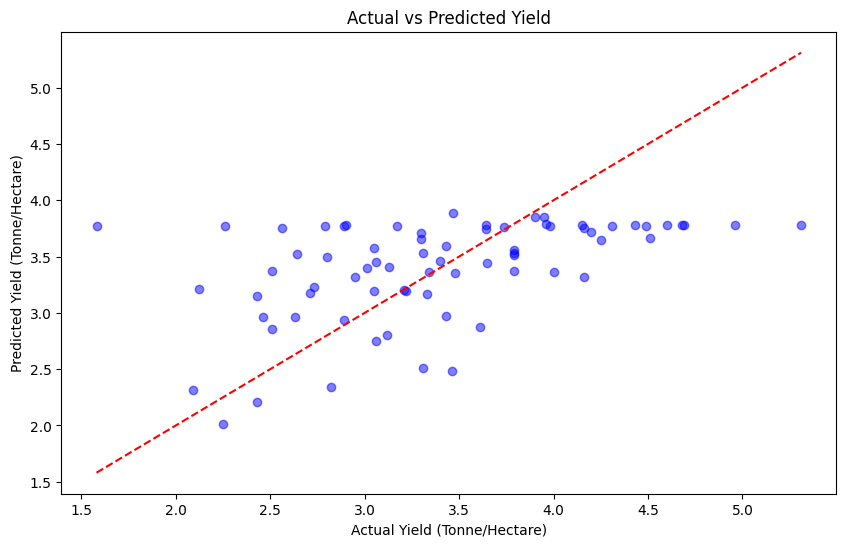

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plot Actual vs Predicted Yield
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')  # Ideal line
plt.title('Actual vs Predicted Yield')
plt.xlabel('Actual Yield (Tonne/Hectare)')
plt.ylabel('Predicted Yield (Tonne/Hectare)')
plt.show()


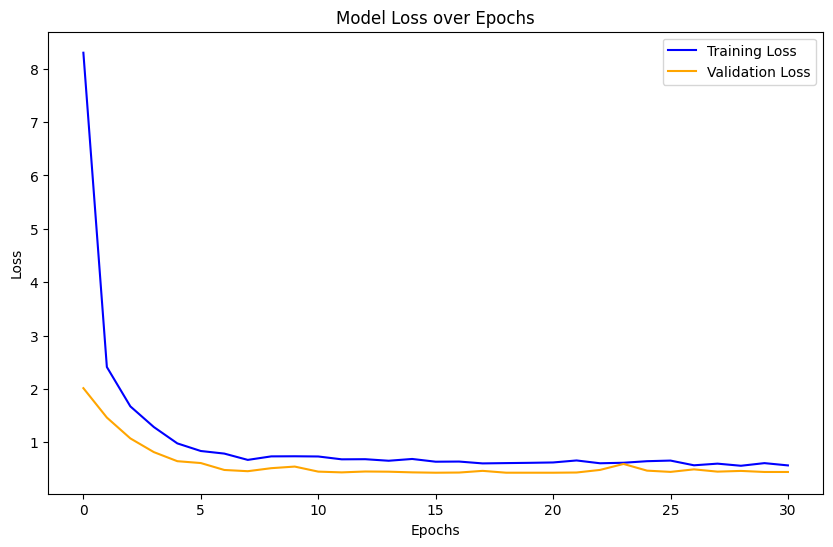

In [ ]:
# Plot Training and Validation Loss over Epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


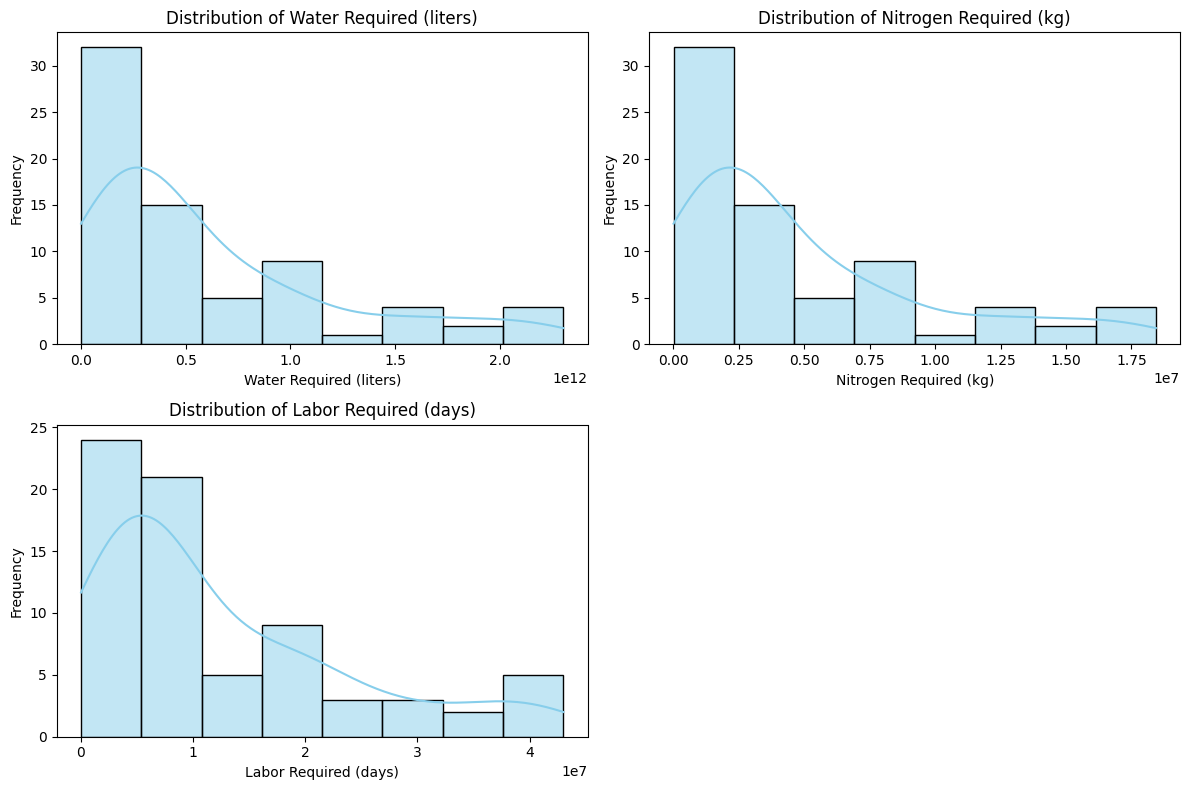

In [ ]:
# Plot the distribution of resource requirements
resources = ['Water Required (liters)', 'Nitrogen Required (kg)', 'Labor Required (days)']

plt.figure(figsize=(12, 8))
for i, resource in enumerate(resources):
    plt.subplot(2, 2, i+1)
    sns.histplot(test_data[resource], kde=True, color='skyblue')
    plt.title(f'Distribution of {resource}')
    plt.xlabel(resource)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


<ipython-input-18-beab896a1b84>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')


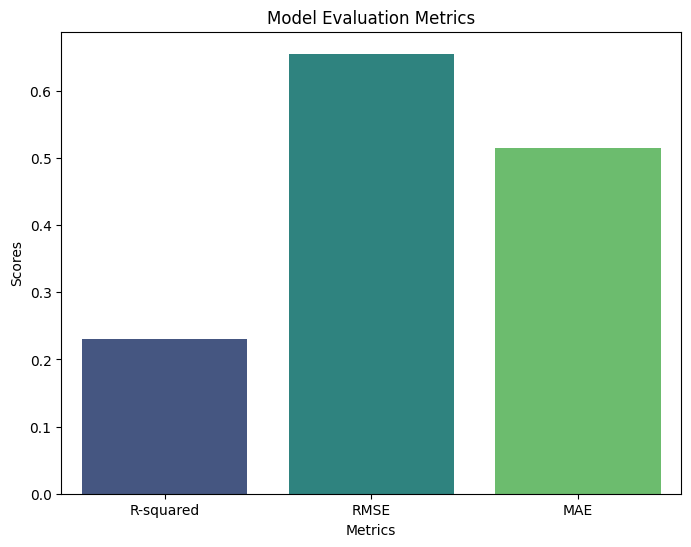

In [ ]:
# Plot RMSE, MAE, and R-Squared scores
metrics = {'R-squared': test_r2, 'RMSE': test_rmse, 'MAE': test_mae}

plt.figure(figsize=(8, 6))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette='viridis')
plt.title('Model Evaluation Metrics')
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.show()


improved harvest time

In [ ]:
# Function to calculate the estimated harvest date
def calculate_harvest_date(row):
    duration = row['duration']

    # Handle missing or invalid duration values
    if isinstance(duration, str):
        if '-' in duration:
            start, end = map(int, duration.split('-'))
            avg_duration = (start + end) / 2
        else:
            avg_duration = float(duration)
    else:
        avg_duration = 0  # Default if duration is missing or invalid

    # Handle NaN values in predicted yield and use a default value if necessary
    predicted_yield = row.get('Predicted_Yield', np.nan)
    if pd.isna(predicted_yield):
        predicted_yield = 0  # Use a default value if predicted yield is NaN

    # Adjust harvest time based on predicted yield (for example, we could use yield * 2 as an adjustment)
    yield_adjustment = predicted_yield * 2  # Example adjustment based on predicted yield
    avg_duration += yield_adjustment

    # Ensure avg_duration is not NaN
    if pd.isna(avg_duration):
        avg_duration = 0  # Set default if it's NaN

    # Calculate the harvest date
    return row['Planting_Date'] + pd.Timedelta(days=int(avg_duration))

# Apply the function to calculate harvest date
southindia_rice['Harvest_Date'] = southindia_rice.apply(calculate_harvest_date, axis=1)

# Select the first 5 samples for display
harvest_info = southindia_rice[['State', 'District', 'Planting_Date', 'Harvest_Date']].head(5)

# Print the results
print(harvest_info)


             State               District Planting_Date Harvest_Date
0   Andhra Pradesh  Alluri sitharama raju    2023-07-16   2023-11-30
1   Andhra Pradesh             Anakapalli    2023-09-17   2024-02-01
2   Andhra Pradesh              Anantapur    2015-01-06   2015-05-23
3   Andhra Pradesh              Anantapur    2016-08-18   2017-01-08
4   Andhra Pradesh              Anantapur    2017-08-11   2017-12-26


F1 SCORE

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, f1_score, classification_report

# Load datasets
southindia_rice = pd.read_csv("southindia_rice.csv")
rainfallstate_data = pd.read_csv("rainfallstate_data.csv")
temperature_data = pd.read_csv("temperature.csv")  # Replace with actual filename

# Merge datasets on 'State' and 'Year'
data = pd.merge(southindia_rice, rainfallstate_data, on=['State', 'Year'])
data = pd.merge(data, temperature_data, on='Year')

# Check for missing data
data = data.dropna()  # Remove rows with missing values

# Convert duration ranges to average values
def convert_duration(duration):
    if '-' in duration:
        start, end = map(int, duration.split('-'))
        return (start + end) / 2
    return float(duration)

# Apply the function to the Duration column
data['duration'] = data['duration'].apply(convert_duration)

# Encode categorical features, including 'State' and 'District'
data_encoded = pd.get_dummies(data, columns=['State', 'District', 'Soil_type', 'Rice_Type'], drop_first=True)

# Select features including temperature
features = [col for col in data_encoded.columns if col not in ['Yield (Tonne/Hectare)']]
X = data_encoded[features]
y = data_encoded['Yield (Tonne/Hectare)']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Squared Exponential Kernel PCA
sekpca = KernelPCA(n_components=30, kernel='rbf', gamma=0.05)  # Experiment with gamma and components
X_sekpca = sekpca.fit_transform(X_scaled)

# Reshape for CNN input
X_cnn = X_sekpca.reshape((X_sekpca.shape[0], X_sekpca.shape[1], 1))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y, test_size=0.2, random_state=42)

# Define the Weight-Tuned Deep CNN model
model = Sequential([
    Conv1D(64, kernel_size=3, input_shape=(X_sekpca.shape[1], 1)),
    LeakyReLU(alpha=0.1),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3),
    LeakyReLU(alpha=0.1),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(256),
    Dropout(0.5),
    Dense(1)  # Single output for yield prediction
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test),
                    callbacks=[early_stopping, lr_scheduler])

# Evaluate the model
y_pred = model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

# Display regression evaluation metrics
print(f'R-squared: {test_r2:.4f}')
print(f'RMSE: {test_rmse:.4f}')
print(f'MAE: {test_mae:.4f}')

# Classification: Calculate F1 Score
# Define a threshold for classification (e.g., median yield in the dataset)
threshold = y.median()

# Create binary labels: 1 for high yield, 0 for low yield
y_test_class = (y_test > threshold).astype(int)
y_pred_class = (y_pred.flatten() > threshold).astype(int)

# Calculate F1 score
f1 = f1_score(y_test_class, y_pred_class)
print(f'F1 Score: {f1:.4f}')

# Generate a full classification report
report = classification_report(y_test_class, y_pred_class, target_names=["Low Yield", "High Yield"])
print("\nClassification Report:\n", report)

# Predict yield and calculate resources
water_per_kg = 2500
nitrogen_per_ton = 20
phosphorus_per_ton = 3
potassium_per_ton = 20
labor_days_per_hectare = 175

# Prepare results DataFrame
test_indices = y_test.index
test_data = data.loc[test_indices]

test_data['Predicted Yield (Tonne/Hectare)'] = y_pred.flatten()
test_data['Water Required (liters)'] = test_data['Area (Hectare)'] * test_data['Predicted Yield (Tonne/Hectare)'] * water_per_kg * 1000
test_data['Nitrogen Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * nitrogen_per_ton * test_data['Area (Hectare)']
test_data['Phosphorus Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * phosphorus_per_ton * test_data['Area (Hectare)']
test_data['Potassium Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * potassium_per_ton * test_data['Area (Hectare)']
test_data['Labor Required (days)'] = labor_days_per_hectare * test_data['Area (Hectare)']

results = pd.DataFrame({
    'State': test_data['State'],
    'District': test_data['District'],
    'Area (hectares)': test_data['Area (Hectare)'],
    'Predicted Yield (Tonne/Hectare)': test_data['Predicted Yield (Tonne/Hectare)'],
    'Water Required (liters)': test_data['Water Required (liters)'],
    'Nitrogen Required (kg)': test_data['Nitrogen Required (kg)'],
    'Phosphorus Required (kg)': test_data['Phosphorus Required (kg)'],
    'Potassium Required (kg)': test_data['Potassium Required (kg)'],
    'Labor Required (days)': test_data['Labor Required (days)']
})

print(results.head())


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 10.4905 - mae: 3.0657 - val_loss: 1.9775 - val_mae: 1.1656 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.5692 - mae: 1.3118 - val_loss: 1.5999 - val_mae: 0.9894 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 1.9740 - mae: 1.0620 - val_loss: 1.1092 - val_mae: 0.8574 - learning_rate: 0.0010
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.2903 - mae: 0.8809 - val_loss: 0.8978 - val_mae: 0.7808 - learning_rate: 0.0010
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1216 - mae: 0.8581 - val_loss: 0.7238 - val_mae: 0.6645 - learning_rate: 0.0010
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.0345 - mae: 0.7516 - val_loss: 0.5696 - val_mae: 0.5985 - learning_rate: 0.0010
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8423 - mae: 0.6639 - val_loss: 0.5003 - val_mae: 0.5749 - learning_rate: 0.0010
Epoch 8/100
9/9 ━━━

In [ ]:
!pip install --upgrade scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 58.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.0
    Uninstalling scikit-learn-1.6.0:
      Successfully uninstalled scikit-learn-1.6.0


test f1 score

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, f1_score, classification_report

# Load datasets
southindia_rice = pd.read_csv("southindia_rice.csv")
rainfallstate_data = pd.read_csv("rainfallstate_data.csv")
temperature_data = pd.read_csv("temperature.csv")  # Replace with actual filename

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Merge datasets on 'State' and 'Year'
data = pd.merge(southindia_rice, rainfallstate_data, on=['State', 'Year'])
data = pd.merge(data, temperature_data, on='Year')

# Check for missing data
data = data.dropna()  # Remove rows with missing values

# Convert duration ranges to average values
def convert_duration(duration):
    if '-' in duration:
        start, end = map(int, duration.split('-'))
        return (start + end) / 2
    return float(duration)

# Apply the function to the Duration column
data['duration'] = data['duration'].apply(convert_duration)

# Encode categorical features, including 'State' and 'District'
data_encoded = pd.get_dummies(data, columns=['State', 'District', 'Soil_type', 'Rice_Type'], drop_first=True)

# Select features including temperature
features = [col for col in data_encoded.columns if col not in ['Yield (Tonne/Hectare)']]
X = data_encoded[features]
y = data_encoded['Yield (Tonne/Hectare)']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Squared Exponential Kernel PCA
sekpca = KernelPCA(n_components=30, kernel='rbf', gamma=0.05)  # Experiment with gamma and components
X_sekpca = sekpca.fit_transform(X_scaled)

# Reshape for CNN input
X_cnn = X_sekpca.reshape((X_sekpca.shape[0], X_sekpca.shape[1], 1))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y, test_size=0.2, random_state=42)

# Define the Weight-Tuned Deep CNN model
model = Sequential([
    Conv1D(64, kernel_size=3, input_shape=(X_sekpca.shape[1], 1)),
    LeakyReLU(alpha=0.1),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3),
    LeakyReLU(alpha=0.1),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(256),
    Dropout(0.5),
    Dense(1)  # Single output for yield prediction
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test),
                    callbacks=[early_stopping, lr_scheduler])

# Evaluate the model
y_pred = model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

# Display regression evaluation metrics
print(f'R-squared: {test_r2:.4f}')
print(f'RMSE: {test_rmse:.4f}')
print(f'MAE: {test_mae:.4f}')

# Classification: Calculate F1 Score
# Define a threshold for classification (e.g., median yield in the dataset)
threshold = y.median()

# Create binary labels: 1 for high yield, 0 for low yield
y_test_class = (y_test > threshold).astype(int)
y_pred_class = (y_pred.flatten() > threshold).astype(int)

# Calculate F1 score
f1 = f1_score(y_test_class, y_pred_class)
print(f'F1 Score: {f1:.4f}')

# Generate a full classification report
report = classification_report(y_test_class, y_pred_class, target_names=["Low Yield", "High Yield"])
print("\nClassification Report:\n", report)

# Predict yield and calculate resources
water_per_kg = 2500
nitrogen_per_ton = 20
phosphorus_per_ton = 3
potassium_per_ton = 20
labor_days_per_hectare = 175

# Prepare results DataFrame
test_indices = y_test.index
test_data = data.loc[test_indices]

test_data['Predicted Yield (Tonne/Hectare)'] = y_pred.flatten()
test_data['Water Required (liters)'] = test_data['Area (Hectare)'] * test_data['Predicted Yield (Tonne/Hectare)'] * water_per_kg * 1000
test_data['Nitrogen Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * nitrogen_per_ton * test_data['Area (Hectare)']
test_data['Phosphorus Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * phosphorus_per_ton * test_data['Area (Hectare)']
test_data['Potassium Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * potassium_per_ton * test_data['Area (Hectare)']
test_data['Labor Required (days)'] = labor_days_per_hectare * test_data['Area (Hectare)']

results = pd.DataFrame({
    'State': test_data['State'],
    'District': test_data['District'],
    'Area (hectares)': test_data['Area (Hectare)'],
    'Predicted Yield (Tonne/Hectare)': test_data['Predicted Yield (Tonne/Hectare)'],
    'Water Required (liters)': test_data['Water Required (liters)'],
    'Nitrogen Required (kg)': test_data['Nitrogen Required (kg)'],
    'Phosphorus Required (kg)': test_data['Phosphorus Required (kg)'],
    'Potassium Required (kg)': test_data['Potassium Required (kg)'],
    'Labor Required (days)': test_data['Labor Required (days)']
})

print(results.head())


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - loss: 10.4012 - mae: 3.0590 - val_loss: 2.0637 - val_mae: 1.1485 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 2.6935 - mae: 1.3290 - val_loss: 1.4851 - val_mae: 0.9924 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.8469 - mae: 1.0625 - val_loss: 1.2020 - val_mae: 0.8582 - learning_rate: 0.0010
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 1.3057 - mae: 0.9033 - val_loss: 0.9825 - val_mae: 0.8411 - learning_rate: 0.0010
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.1174 - mae: 0.8086 - val_loss: 0.7704 - val_mae: 0.6833 - learning_rate: 0.0010
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.9461 - mae: 0.7262 - val_loss: 0.5950 - val_mae: 0.6185 - learning_rate: 0.0010
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8269 - mae: 0.6687 - val_loss: 0.5057 - val_mae: 0.5841 - learning_rate: 0.0010
Epoch 8/100
9/9 ━━

LAST FINAL CODE WITH FULL REQUIREMENT

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, f1_score, classification_report

# Load datasets
southindia_rice = pd.read_csv("southindia_rice.csv")
rainfallstate_data = pd.read_csv("rainfallstate_data.csv")
temperature_data = pd.read_csv("temperature.csv")  # Replace with actual filename

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Merge datasets on 'State' and 'Year'
data = pd.merge(southindia_rice, rainfallstate_data, on=['State', 'Year'])
data = pd.merge(data, temperature_data, on='Year')

# Check for missing data
data = data.dropna()  # Remove rows with missing values

# Convert duration ranges to average values
def convert_duration(duration):
    if '-' in duration:
        start, end = map(int, duration.split('-'))
        return (start + end) / 2
    return float(duration)

# Apply the function to the Duration column
data['duration'] = data['duration'].apply(convert_duration)

# Encode categorical features, including 'State' and 'District'
data_encoded = pd.get_dummies(data, columns=['State', 'District', 'Soil_type', 'Rice_Type'], drop_first=True)

# Select features including temperature
features = [col for col in data_encoded.columns if col not in ['Yield (Tonne/Hectare)']]
X = data_encoded[features]
y = data_encoded['Yield (Tonne/Hectare)']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply Squared Exponential Kernel PCA
sekpca = KernelPCA(n_components=30, kernel='rbf', gamma=0.05)  # Experiment with gamma and components
X_sekpca = sekpca.fit_transform(X_scaled)

# Reshape for CNN input
X_cnn = X_sekpca.reshape((X_sekpca.shape[0], X_sekpca.shape[1], 1))

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_cnn, y, test_size=0.2, random_state=42)

# Define the Weight-Tuned Deep CNN model
model = Sequential([
    Conv1D(64, kernel_size=3, input_shape=(X_sekpca.shape[1], 1)),
    LeakyReLU(alpha=0.1),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3),
    LeakyReLU(alpha=0.1),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(256),
    Dropout(0.5),
    Dense(1)  # Single output for yield prediction
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test),
                    callbacks=[early_stopping, lr_scheduler])

# Evaluate the model
y_pred = model.predict(X_test)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

# Display regression evaluation metrics
print(f'R-squared: {test_r2:.4f}')
print(f'RMSE: {test_rmse:.4f}')
print(f'MAE: {test_mae:.4f}')

# MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - y_pred.flatten()) / y_test)) * 100
print(f'MAPE: {mape:.4f}%')

# Test accuracy calculation (1 - MAPE)
test_accuracy = 100 - mape  # 1 - MAPE
print(f'Test Accuracy: {test_accuracy:.4f}%')

# Classification: Calculate F1 Score
# Define a threshold for classification (e.g., median yield in the dataset)
threshold = y.median()

# Create binary labels: 1 for high yield, 0 for low yield
y_test_class = (y_test > threshold).astype(int)
y_pred_class = (y_pred.flatten() > threshold).astype(int)

# Calculate F1 score
f1 = f1_score(y_test_class, y_pred_class)
print(f'F1 Score: {f1:.4f}')

# Generate a full classification report
report = classification_report(y_test_class, y_pred_class, target_names=["Low Yield", "High Yield"])
print("\nClassification Report:\n", report)

# Predict yield and calculate resources
water_per_kg = 2500
nitrogen_per_ton = 20
phosphorus_per_ton = 3
potassium_per_ton = 20
labor_days_per_hectare = 175

# Prepare results DataFrame
test_indices = y_test.index
test_data = data.loc[test_indices]

test_data['Predicted Yield (Tonne/Hectare)'] = y_pred.flatten()
test_data['Water Required (liters)'] = test_data['Area (Hectare)'] * test_data['Predicted Yield (Tonne/Hectare)'] * water_per_kg * 1000
test_data['Nitrogen Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * nitrogen_per_ton * test_data['Area (Hectare)']
test_data['Phosphorus Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * phosphorus_per_ton * test_data['Area (Hectare)']
test_data['Potassium Required (kg)'] = test_data['Predicted Yield (Tonne/Hectare)'] * potassium_per_ton * test_data['Area (Hectare)']
test_data['Labor Required (days)'] = labor_days_per_hectare * test_data['Area (Hectare)']

results = pd.DataFrame({
    'State': test_data['State'],
    'District': test_data['District'],
    'Area (hectares)': test_data['Area (Hectare)'],
    'Predicted Yield (Tonne/Hectare)': test_data['Predicted Yield (Tonne/Hectare)'],
    'Water Required (liters)': test_data['Water Required (liters)'],
    'Nitrogen Required (kg)': test_data['Nitrogen Required (kg)'],
    'Phosphorus Required (kg)': test_data['Phosphorus Required (kg)'],
    'Potassium Required (kg)': test_data['Potassium Required (kg)'],
    'Labor Required (days)': test_data['Labor Required (days)']
})

print(results.head())


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - loss: 10.4012 - mae: 3.0590 - val_loss: 2.0637 - val_mae: 1.1485 - learning_rate: 0.0010
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 2.6935 - mae: 1.3290 - val_loss: 1.4851 - val_mae: 0.9924 - learning_rate: 0.0010
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 1.8469 - mae: 1.0625 - val_loss: 1.2020 - val_mae: 0.8582 - learning_rate: 0.0010
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 1.3057 - mae: 0.9033 - val_loss: 0.9825 - val_mae: 0.8411 - learning_rate: 0.0010
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.1174 - mae: 0.8086 - val_loss: 0.7704 - val_mae: 0.6833 - learning_rate: 0.0010
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.9461 - mae: 0.7262 - val_loss: 0.5950 - val_mae: 0.6185 - learning_rate: 0.0010
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8269 - mae: 0.6687 - val_loss: 0.5057 - val_mae: 0.5841 - learning_rate: 0.0010
Epoch 8/100
9/9 ━━━

f1 diagram

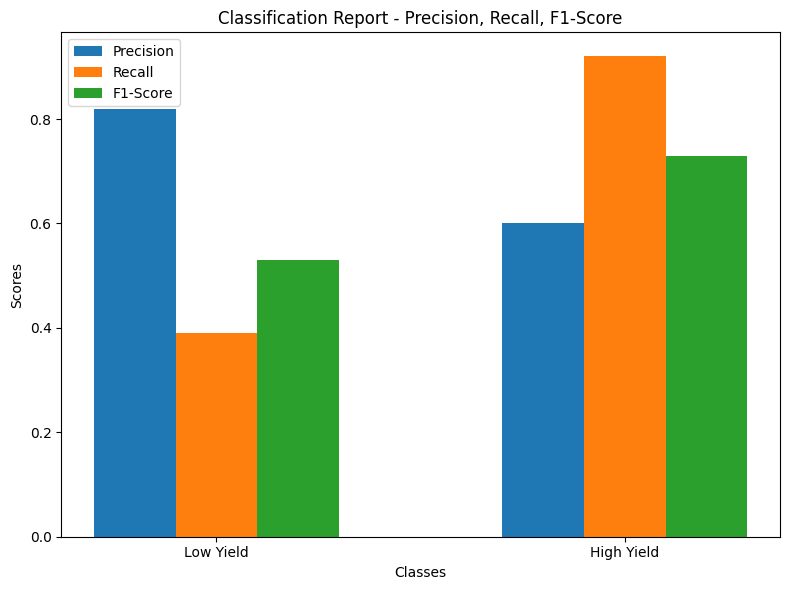

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Classification metrics
labels = ['Low Yield', 'High Yield']
precision = [0.82, 0.60]
recall = [0.39, 0.92]
f1_score = [0.53, 0.73]

x = np.arange(len(labels))  # The label locations

# Create the bar chart
width = 0.2  # Width of the bars

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision')
bars2 = ax.bar(x, recall, width, label='Recall')
bars3 = ax.bar(x + width, f1_score, width, label='F1-Score')

# Add some text for labels, title and custom x-axis tick labels
ax.set_xlabel('Classes')
ax.set_ylabel('Scores')
ax.set_title('Classification Report - Precision, Recall, F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Display the bar chart
plt.tight_layout()
plt.show()


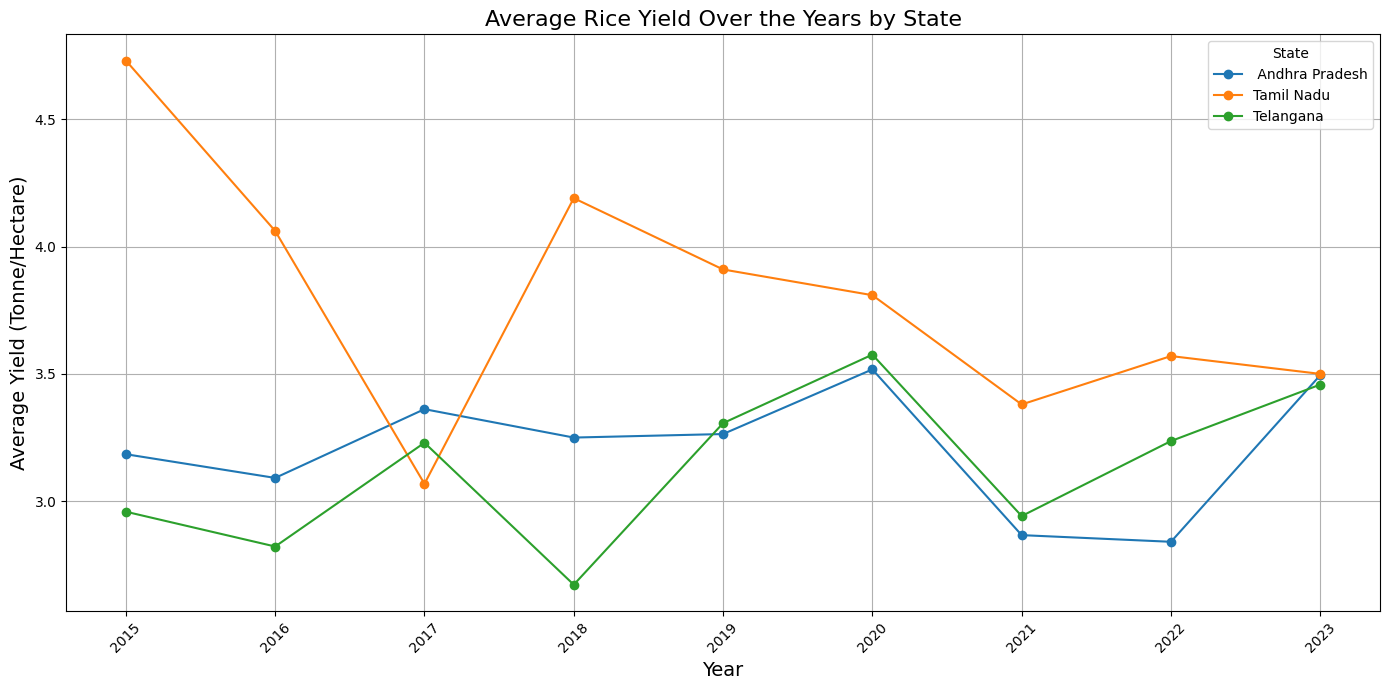

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the datasets
southindia_rice = pd.read_csv("southindia_rice.csv")
rainfallstate_data = pd.read_csv("rainfallstate_data.csv")

# Merge datasets on 'State' and 'Year'
data = pd.merge(southindia_rice, rainfallstate_data, on=['State', 'Year'])

# Convert relevant columns to numeric, ignoring errors
data['Yield (Tonne/Hectare)'] = pd.to_numeric(data['Yield (Tonne/Hectare)'], errors='coerce')

# Drop rows with NaN values in 'Year' and 'Yield (Tonne/Hectare)'
data.dropna(subset=['Year', 'Yield (Tonne/Hectare)'], inplace=True)

# Group by Year and State to get average yield
average_yield = data.groupby(['Year', 'State'])['Yield (Tonne/Hectare)'].mean().reset_index()

# Set the figure size
plt.figure(figsize=(14, 7))

# Plotting for each state
for state in average_yield['State'].unique():
    state_data = average_yield[average_yield['State'] == state]
    plt.plot(state_data['Year'], state_data['Yield (Tonne/Hectare)'], marker='o', label=state)

# Adding titles and labels
plt.title('Average Rice Yield Over the Years by State', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Yield (Tonne/Hectare)', fontsize=14)
plt.xticks(average_yield['Year'].unique(), rotation=45)
plt.legend(title='State')
plt.grid()

# Show the plot
plt.tight_layout()
plt.show()


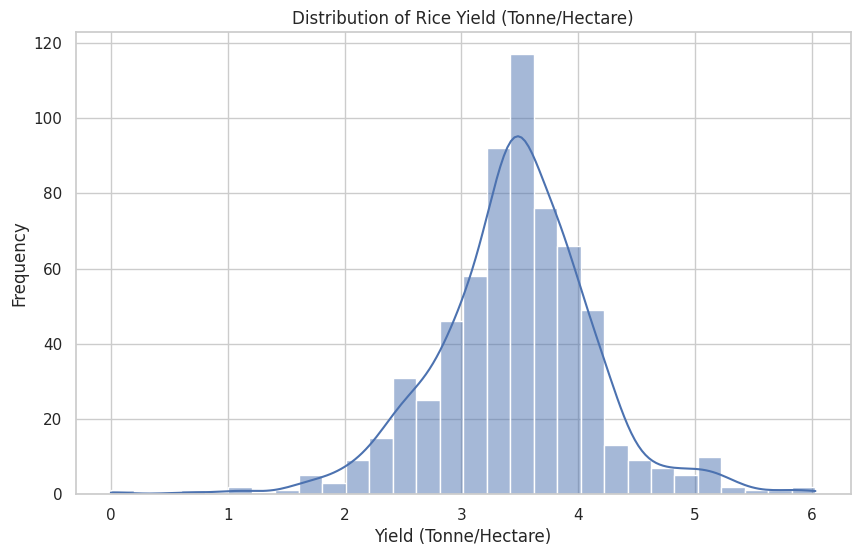

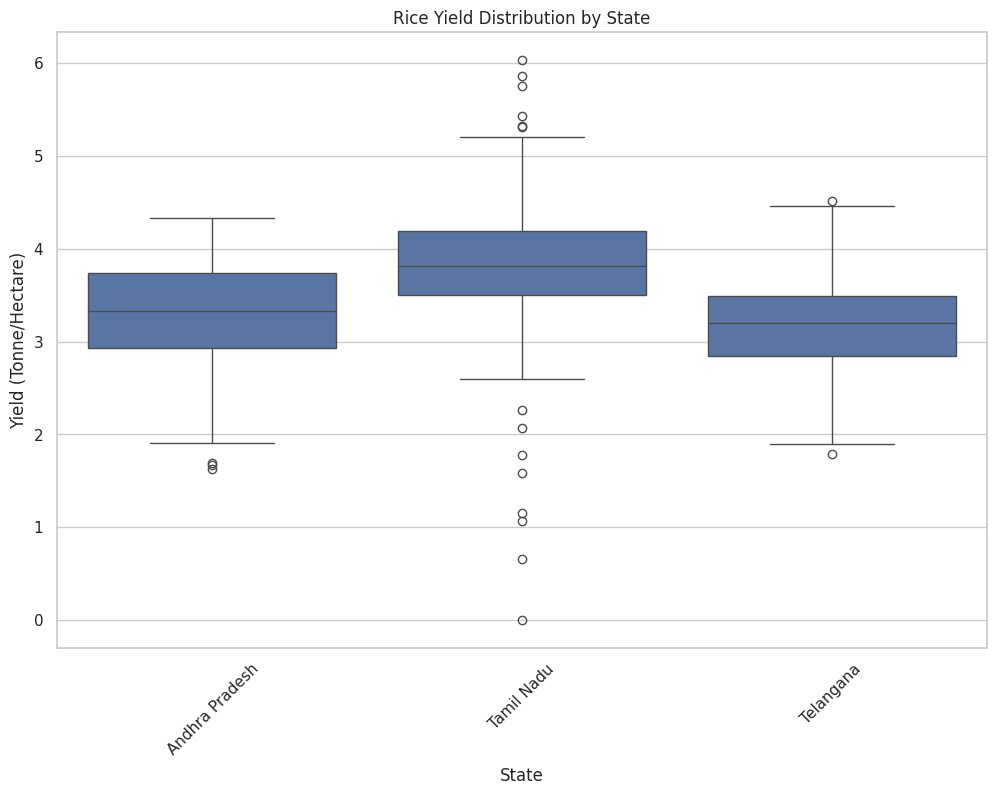

ValueError: could not convert string to float: ' Andhra Pradesh'

<Figure size 1200x1000 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
southindia_rice = pd.read_csv("southindia_rice.csv")
rainfallstate_data = pd.read_csv("rainfallstate_data.csv")

# Merge datasets on 'State' and 'Year'
data = pd.merge(southindia_rice, rainfallstate_data, on=['State', 'Year'])

# Set the aesthetic style of the plots
sns.set(style="whitegrid")

# 1. Yield Distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['Yield (Tonne/Hectare)'], bins=30, kde=True)
plt.title('Distribution of Rice Yield (Tonne/Hectare)')
plt.xlabel('Yield (Tonne/Hectare)')
plt.ylabel('Frequency')
plt.show()

# 2. Boxplot of Yield by State
plt.figure(figsize=(12, 8))
sns.boxplot(x='State', y='Yield (Tonne/Hectare)', data=data)
plt.title('Rice Yield Distribution by State')
plt.xlabel('State')
plt.ylabel('Yield (Tonne/Hectare)')
plt.xticks(rotation=45)
plt.show()

# 3. Heatmap of Correlation Matrix
plt.figure(figsize=(12, 10))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar=True)
plt.title('Correlation Matrix of Features')
plt.show()

# 4. Resource Requirement Visualization
# Assuming 'results' DataFrame is created as in previous code
results = pd.DataFrame({
    'State': ['State1', 'State2', 'State3'],  # Example states
    'Water Required (liters)': [5000, 6000, 7000],  # Example values
    'Nitrogen Required (kg)': [200, 250, 300],  # Example values
    'Phosphorus Required (kg)': [30, 35, 40],  # Example values
    'Potassium Required (kg)': [250, 300, 350],  # Example values
    'Labor Required (days)': [150, 175, 200]  # Example values
})

# Melt the DataFrame for better plotting
resources_melted = results.melt(id_vars='State', var_name='Resource', value_name='Amount')

plt.figure(figsize=(12, 8))
sns.barplot(x='Resource', y='Amount', hue='State', data=resources_melted)
plt.title('Resource Requirements per State')
plt.xlabel('Resource Type')
plt.ylabel('Amount')
plt.xticks(rotation=45)
plt.legend(title='State')
plt.show()

# 5. Predicted vs Actual Yield
# Assuming `y_test` and `predictions` are available
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.title('Predicted vs Actual Yield')
plt.xlabel('Actual Yield (Tonne/Hectare)')
plt.ylabel('Predicted Yield (Tonne/Hectare)')
plt.grid()
plt.show()


In [ ]:
import pandas as pd

# Load the dataset
southindia_rice = pd.read_csv("southindia_rice.csv")

# Calculate mean and standard deviation for Area and Yield
area_mean = southindia_rice['Area (Hectare)'].mean()
area_std = southindia_rice['Area (Hectare)'].std()

yield_mean = southindia_rice['Yield (Tonne/Hectare)'].mean()
yield_std = southindia_rice['Yield (Tonne/Hectare)'].std()

# Print the values
print(f"Mean of Area: {area_mean}")
print(f"Standard Deviation of Area: {area_std}")
print(f"Mean of Yield: {yield_mean}")
print(f"Standard Deviation of Yield: {yield_std}")


Mean of Area: 327078.24100327154
Standard Deviation of Area: 696871.1935152357
Mean of Yield: 3.2568909487459106
Standard Deviation of Yield: 0.7772505476736795
